# 🔴⚫ THOMASSON ENGINE v5.0
## Système d'Identification du Successeur d'Adrien Thomasson — RC Lens
---
> **Auteur :** Cellule Data RC Lens  
> **Dataset :** SofaScore Big 5 — 2024/25  
> **Joueur cible :** Adrien Thomasson — Milieu hybride (Box-to-Box)  
> **Objectif :** Identifier scientifiquement les 5 meilleurs profils de remplacement via un modèle composite multicritère

---
### 📋 Table des Matières
1. [Setup & Chargement des données](#1-setup)
2. [Portrait statistique de Thomasson](#2-portrait)
3. [Construction du modèle de scoring](#3-modele)
4. [Benchmark comparatif des candidats](#4-benchmark)
5. [Visualisations avancées](#5-viz)
6. [Classement final & Recommandations](#6-final)


## 1. Setup & Chargement des Données <a id='1-setup'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# ─── Palette RC Lens ──────────────────────────────────────────────────────────
LENS_ROUGE    = '#E30613'
LENS_NOIR     = '#1A1A1A'
LENS_OR       = '#F5A623'
LENS_GRIS     = '#8C8C8C'
LENS_FOND     = '#0F0F0F'
LENS_BLANC    = '#F2F2F2'
ACCENT_BLEU   = '#00A8E8'

plt.rcParams.update({
    'figure.facecolor': LENS_FOND,
    'axes.facecolor':   LENS_FOND,
    'text.color':       LENS_BLANC,
    'axes.labelcolor':  LENS_BLANC,
    'xtick.color':      LENS_GRIS,
    'ytick.color':      LENS_GRIS,
    'axes.edgecolor':   '#2A2A2A',
    'axes.grid':        True,
    'grid.color':       '#1F1F1F',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        10,
})

print("✅ Librairies chargées")
print(f"   Palette RC Lens activée : ⚫ Noir | 🔴 Rouge | 🟡 Or")


✅ Librairies chargées
   Palette RC Lens activée : ⚫ Noir | 🔴 Rouge | 🟡 Or


In [2]:
# ─── Chargement & nettoyage ───────────────────────────────────────────────────
df_raw = pd.read_csv('big5_stats.csv', sep=';', on_bad_lines='skip')

COLS_NUM = [
    'minutesPlayed','rating','goals','assists','expectedGoals','expectedAssists',
    'keyPasses','tackles','interceptions','accuratePassesPercentage',
    'successfulDribbles','bigChancesCreated','fouls','wasFouled','totalShots',
    'shotsOnTarget','groundDuelsWonPercentage','aerialDuelsWonPercentage',
    'totalDuelsWonPercentage','player_age','appearances','accurateFinalThirdPasses',
    'totalPasses','possessionLost','clearances','yellowCards',
    'accurateCrosses','accurateCrossesPercentage'
]
for col in COLS_NUM:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Déduplication : conserver les données les plus riches par joueur
df = (df_raw
      .dropna(subset=['player__name','minutesPlayed','rating'])
      .sort_values('minutesPlayed', ascending=False)
      .drop_duplicates('player__name', keep='first')
      .query('minutesPlayed >= 600')
      .copy())

# Normalisation per 90 minutes
df['p90'] = df['minutesPlayed'] / 90
P90_COLS = ['goals','assists','expectedGoals','expectedAssists','keyPasses',
            'tackles','interceptions','bigChancesCreated','totalShots',
            'successfulDribbles','fouls','wasFouled','accurateFinalThirdPasses',
            'possessionLost','clearances','accurateCrosses']
for c in P90_COLS:
    df[f'{c}_p90'] = df[c] / df['p90']

# Filtrage milieux
mf = df[df['player_position'].str.contains('MF', na=False)].copy().reset_index(drop=True)

print(f"✅ Dataset chargé et nettoyé")
print(f"   Joueurs totaux (≥600 min) : {len(df):,}")
print(f"   Milieux de terrain        : {len(mf):,}")
print(f"   Ligues couvertes           : {', '.join(mf['league_name'].dropna().unique())}")
print(f"   Équipes représentées       : {mf['team__name'].nunique()}")


✅ Dataset chargé et nettoyé
   Joueurs totaux (≥600 min) : 1,469
   Milieux de terrain        : 717
   Ligues couvertes           : Premier League, Serie A, La liga, Bundesliga, Ligue 1
   Équipes représentées       : 96


## 2. Portrait Statistique d'Adrien Thomasson <a id='2-portrait'></a>

> Le préalable indispensable : comprendre scientifiquement l'ADN de jeu du joueur à remplacer.

In [3]:
# ─── Isolation du profil Thomasson ───────────────────────────────────────────
THOMASSON = mf[mf['player__name'].str.contains('Thomasson', na=False, case=False)].iloc[0]

print("=" * 60)
print("⚫🔴 PROFIL STATISTIQUE — ADRIEN THOMASSON")
print("=" * 60)
print(f"  Équipe         : {THOMASSON['team__name']} | {THOMASSON['league_name']}")
print(f"  Âge            : {THOMASSON['player_age']:.0f} ans | {THOMASSON['player_nation']}")
print(f"  Poste          : Milieu hybride (Box-to-Box créatif)")
print(f"  Minutes jouées : {THOMASSON['minutesPlayed']:.0f} min ({THOMASSON['appearances']:.0f} matchs)")
print(f"  Note SofaScore : {THOMASSON['rating']:.2f}/10")
print()
print("  ─── CONTRIBUTION OFFENSIVE (per 90) ──────────────────")
print(f"  Buts           : {THOMASSON['goals_p90']:.3f}  | xG/90 : {THOMASSON['expectedGoals_p90']:.3f}")
print(f"  Passes déc.    : {THOMASSON['assists_p90']:.3f} | xA/90 : {THOMASSON['expectedAssists_p90']:.3f}")
print(f"  Passes clés    : {THOMASSON['keyPasses_p90']:.2f}  | Big chances créées : {THOMASSON['bigChancesCreated_p90']:.3f}")
print(f"  Dribbles réuss.: {THOMASSON['successfulDribbles_p90']:.3f}")
print()
print("  ─── PRESSING & DUELS (per 90) ─────────────────────────")
print(f"  Tacles         : {THOMASSON['tackles_p90']:.2f}  | Intercept. : {THOMASSON['interceptions_p90']:.3f}")
print(f"  Duels sol gagnés : {THOMASSON['groundDuelsWonPercentage']:.1f}%")
print(f"  Duels aériens   : {THOMASSON['aerialDuelsWonPercentage']:.1f}%")
print()
print("  ─── CIRCULATION DU JEU ────────────────────────────────")
print(f"  Précision passes : {THOMASSON['accuratePassesPercentage']:.1f}%")
print(f"  Passes T. final  : {THOMASSON['accurateFinalThirdPasses_p90']:.2f}/90")
print("=" * 60)


⚫🔴 PROFIL STATISTIQUE — ADRIEN THOMASSON
  Équipe         : RC Lens | Ligue 1
  Âge            : 32 ans | FRA
  Poste          : Milieu hybride (Box-to-Box créatif)
  Minutes jouées : 1922 min (22 matchs)
  Note SofaScore : 6.88/10

  ─── CONTRIBUTION OFFENSIVE (per 90) ──────────────────
  Buts           : 0.094  | xG/90 : 0.217
  Passes déc.    : 0.281 | xA/90 : 0.190
  Passes clés    : 2.43  | Big chances créées : 0.328
  Dribbles réuss.: 0.515

  ─── PRESSING & DUELS (per 90) ─────────────────────────
  Tacles         : 2.95  | Intercept. : 0.656
  Duels sol gagnés : 44.2%
  Duels aériens   : 40.0%

  ─── CIRCULATION DU JEU ────────────────────────────────
  Précision passes : 83.2%
  Passes T. final  : 10.30/90


### 2.1 Radar Chart — DNA de jeu de Thomasson

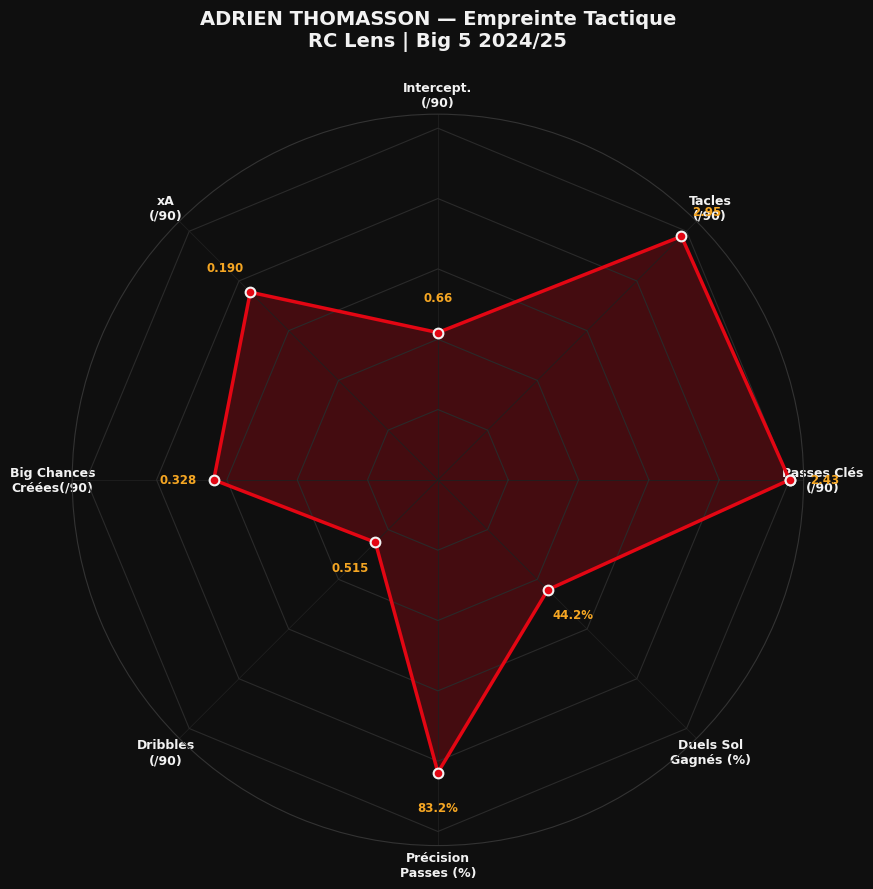

✅ Radar Thomasson généré


In [4]:
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True), 
                        facecolor=LENS_FOND)
ax.set_facecolor(LENS_FOND)

categories = [
    'Passes Clés\n(/90)', 'Tacles\n(/90)', 'Intercept.\n(/90)',
    'xA\n(/90)', 'Big Chances\nCréées(/90)', 'Dribbles\n(/90)',
    'Précision\nPasses (%)', 'Duels Sol\nGagnés (%)'
]
N = len(categories)

# Valeurs Thomasson (normalisées sur le pool MF)
raw_vals = [
    THOMASSON['keyPasses_p90'], THOMASSON['tackles_p90'],
    THOMASSON['interceptions_p90'], THOMASSON['expectedAssists_p90'],
    THOMASSON['bigChancesCreated_p90'], THOMASSON['successfulDribbles_p90'],
    THOMASSON['accuratePassesPercentage']/100, THOMASSON['groundDuelsWonPercentage']/100
]
cols_radar = ['keyPasses_p90','tackles_p90','interceptions_p90','expectedAssists_p90',
              'bigChancesCreated_p90','successfulDribbles_p90']
max_vals = [mf['keyPasses_p90'].quantile(0.95), mf['tackles_p90'].quantile(0.95),
            mf['interceptions_p90'].quantile(0.95), mf['expectedAssists_p90'].quantile(0.95),
            mf['bigChancesCreated_p90'].quantile(0.95), mf['successfulDribbles_p90'].quantile(0.95),
            1.0, 1.0]
vals = [min(v/m, 1.0) for v, m in zip(raw_vals, max_vals)]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
vals += vals[:1]

# Grilles
for r in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot(angles, [r]*len(angles), '-', color='#2A2A2A', lw=0.8)
    ax.fill(angles, [r]*len(angles), alpha=0.0)

# Zone ombragée remplie
ax.fill(angles, vals, color=LENS_ROUGE, alpha=0.25)
ax.plot(angles, vals, 'o-', color=LENS_ROUGE, lw=2.5, ms=7, 
        mfc=LENS_ROUGE, mec=LENS_BLANC, mew=1.5)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9, color=LENS_BLANC, fontweight='bold')
ax.set_yticks([])
ax.spines['polar'].set_color('#333333')

# Valeurs sur les points
raw_display = [
    f"{THOMASSON['keyPasses_p90']:.2f}", f"{THOMASSON['tackles_p90']:.2f}",
    f"{THOMASSON['interceptions_p90']:.2f}", f"{THOMASSON['expectedAssists_p90']:.3f}",
    f"{THOMASSON['bigChancesCreated_p90']:.3f}", f"{THOMASSON['successfulDribbles_p90']:.3f}",
    f"{THOMASSON['accuratePassesPercentage']:.1f}%", f"{THOMASSON['groundDuelsWonPercentage']:.1f}%"
]
for angle, val, label in zip(angles[:-1], vals[:-1], raw_display):
    ax.annotate(label, xy=(angle, val), xytext=(angle, val+0.1),
                ha='center', va='center', fontsize=8.5, color=LENS_OR, fontweight='bold')

ax.set_title("ADRIEN THOMASSON — Empreinte Tactique\nRC Lens | Big 5 2024/25",
             color=LENS_BLANC, fontsize=14, fontweight='bold', pad=25)
plt.tight_layout()
plt.savefig('thomasson_radar.png', dpi=150, bbox_inches='tight', facecolor=LENS_FOND)
plt.show()
print("✅ Radar Thomasson généré")


### 2.2 Thomasson dans le contexte des milieux Big 5

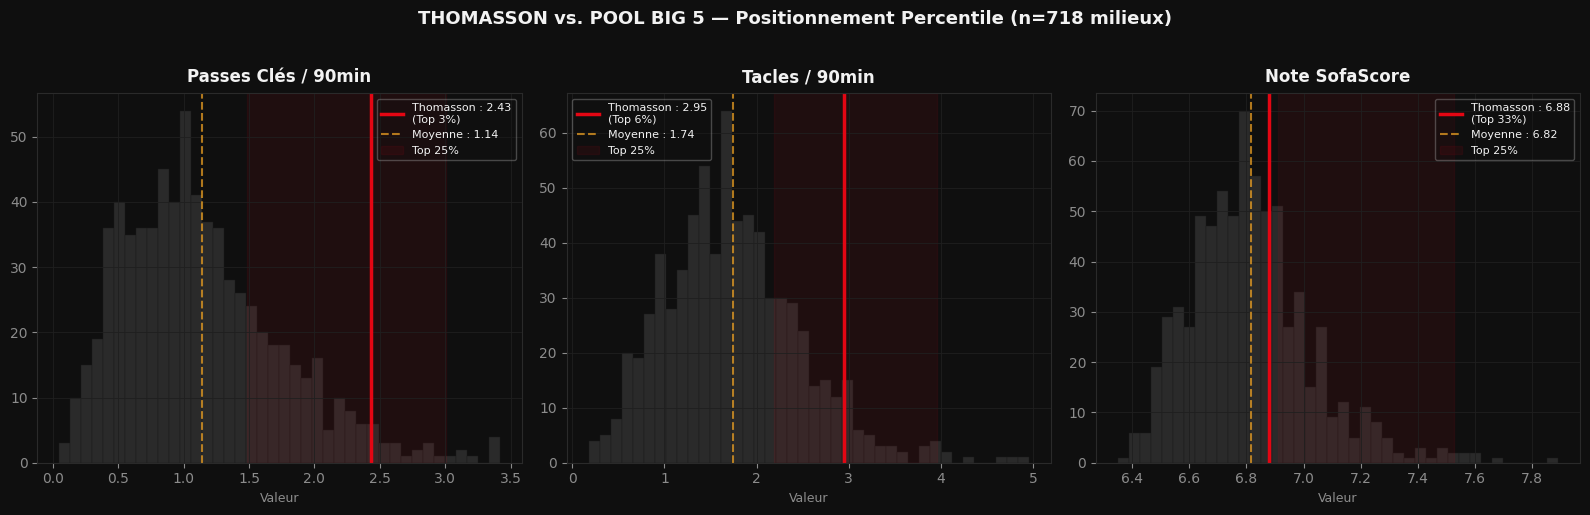

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=LENS_FOND)

metrics = [
    ('keyPasses_p90', 'Passes Clés / 90min', THOMASSON['keyPasses_p90']),
    ('tackles_p90', 'Tacles / 90min', THOMASSON['tackles_p90']),
    ('rating', 'Note SofaScore', THOMASSON['rating']),
]

for ax, (col, title, t_val) in zip(axes, metrics):
    data = mf[col].dropna()
    pct = (data < t_val).mean() * 100
    
    ax.hist(data, bins=40, color='#2A2A2A', edgecolor='#1A1A1A', linewidth=0.3)
    ax.axvline(t_val, color=LENS_ROUGE, lw=2.5, label=f'Thomasson : {t_val:.2f}\n(Top {100-pct:.0f}%)')
    ax.axvline(data.mean(), color=LENS_OR, lw=1.5, ls='--', alpha=0.7, label=f'Moyenne : {data.mean():.2f}')
    
    # Zone percentile
    q75 = data.quantile(0.75)
    ax.axvspan(q75, data.quantile(0.99), alpha=0.08, color=LENS_ROUGE, label='Top 25%')
    
    ax.set_title(title, color=LENS_BLANC, fontweight='bold', pad=8)
    ax.legend(fontsize=8, framealpha=0.3, labelcolor=LENS_BLANC)
    ax.set_xlabel('Valeur', color=LENS_GRIS, fontsize=9)

fig.suptitle("THOMASSON vs. POOL BIG 5 — Positionnement Percentile (n=718 milieux)",
             color=LENS_BLANC, fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('thomasson_distribution.png', dpi=150, bbox_inches='tight', facecolor=LENS_FOND)
plt.show()


## 3. Construction du Modèle de Scoring Composite <a id='3-modele'></a>

> **Philosophie :** Thomasson est un **milieu hybride Box-to-Box** qui allie pressing intense et création offensive. Le modèle reflète cet équilibre à travers 3 dimensions pondérées.

In [6]:
# ─── Matrice de pondération ───────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════╗")
print("║          MATRICE DE PONDÉRATION — THOMASSON ENGINE       ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  DIMENSION 1 : PRESSING & RÉCUPÉRATION        (45%)     ║")
print("║   ├─ Tacles /90                                [30%]    ║")
print("║   ├─ Interceptions /90                         [20%]    ║")
print("║   ├─ Duels sol gagnés (%)                      [20%]    ║")
print("║   ├─ Dégagements /90                           [10%]    ║")
print("║   ├─ Fautes provoquées /90                     [10%]    ║")
print("║   └─ Note SofaScore                            [10%]    ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  DIMENSION 2 : CRÉATION & PROJECTION          (45%)     ║")
print("║   ├─ Passes clés /90                           [30%]    ║")
print("║   ├─ Big chances créées /90                    [25%]    ║")
print("║   ├─ Passes décisives /90                      [20%]    ║")
print("║   ├─ xA /90                                    [15%]    ║")
print("║   └─ Dribbles réussis /90                      [10%]    ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  DIMENSION 3 : CIRCULATION DU JEU             (10%)     ║")
print("║   └─ Précision des passes (%)                  [100%]   ║")
print("╚══════════════════════════════════════════════════════════╝")

# ─── Calcul des scores ────────────────────────────────────────────────────────
mf['score_pressing'] = (
    mf['tackles_p90'].fillna(0)               * 0.30 +
    mf['interceptions_p90'].fillna(0)          * 0.20 +
    mf['groundDuelsWonPercentage'].fillna(0)/100 * 0.20 +
    mf['clearances_p90'].fillna(0)             * 0.10 +
    mf['fouls_p90'].fillna(0)                  * 0.10 +
    mf['rating'].fillna(0)                     * 0.10
)
mf['score_creation'] = (
    mf['keyPasses_p90'].fillna(0)              * 0.30 +
    mf['bigChancesCreated_p90'].fillna(0)       * 0.25 +
    mf['assists_p90'].fillna(0)                * 0.20 +
    mf['expectedAssists_p90'].fillna(0)        * 0.15 +
    mf['successfulDribbles_p90'].fillna(0)     * 0.10
)
mf['score_final'] = (
    mf['score_pressing'] * 0.45 +
    mf['score_creation'] * 0.45 +
    mf['accuratePassesPercentage'].fillna(0)/100 * 0.10
)

# Normalisation 0-100
for s in ['score_final','score_pressing','score_creation']:
    mf[f'{s}_norm'] = MinMaxScaler((0,100)).fit_transform(mf[[s]])

# Score Thomasson
t_scores = mf[mf['player__name'].str.contains('Thomasson', na=False)].iloc[0]
print(f"\n📊 SCORES THOMASSON :")
print(f"   Score Final    : {t_scores['score_final_norm']:.1f}/100")
print(f"   Score Pressing : {t_scores['score_pressing_norm']:.1f}/100")
print(f"   Score Création : {t_scores['score_creation_norm']:.1f}/100")
print(f"   Percentile     : {(mf['score_final_norm'] < t_scores['score_final_norm']).mean()*100:.0f}ème")


╔══════════════════════════════════════════════════════════╗
║          MATRICE DE PONDÉRATION — THOMASSON ENGINE       ║
╠══════════════════════════════════════════════════════════╣
║  DIMENSION 1 : PRESSING & RÉCUPÉRATION        (45%)     ║
║   ├─ Tacles /90                                [30%]    ║
║   ├─ Interceptions /90                         [20%]    ║
║   ├─ Duels sol gagnés (%)                      [20%]    ║
║   ├─ Dégagements /90                           [10%]    ║
║   ├─ Fautes provoquées /90                     [10%]    ║
║   └─ Note SofaScore                            [10%]    ║
╠══════════════════════════════════════════════════════════╣
║  DIMENSION 2 : CRÉATION & PROJECTION          (45%)     ║
║   ├─ Passes clés /90                           [30%]    ║
║   ├─ Big chances créées /90                    [25%]    ║
║   ├─ Passes décisives /90                      [20%]    ║
║   ├─ xA /90                                    [15%]    ║
║   └─ Dribbles réussis /90         

## 4. Benchmark Comparatif — Top 5 Candidats <a id='4-benchmark'></a>

In [24]:
# Filtrage : ≤28 ans, hors Thomasson, hors trop purs défenseurs
EXCLUS = ['Adrien Thomasson', 'Lamine Yamal', 'Patrizio Masini']
candidats = mf[
    ~mf['player__name'].isin(EXCLUS) &
    (mf['player_age'] <= 28) &
    (mf['score_creation_norm'] >= 20)  # doit avoir une dimension créative
].copy()

TOP5 = candidats.nlargest(5, 'score_final_norm').reset_index(drop=True)
THOMASSON_ROW = mf[mf['player__name'].str.contains('Thomasson', na=False)].iloc[0]

print("┌─────────────────────────────────────────────────────────────────┐")
print("│          TOP 5 REMPLAÇANTS IDENTIFIÉS — THOMASSON ENGINE        │")
print("├───┬──────────────────────┬──────────────┬────┬──────┬─────┬─────┤")
print("│ # │ Joueur               │ Club         │Age │Score │Press│Créa │")
print("├───┼──────────────────────┼──────────────┼────┼──────┼─────┼─────┤")
for i, row in TOP5.iterrows():
    print(f"│{i+1:>2} │ {row['player__name']:<20} │ {row['team__name']:<12} │{row['player_age']:>3.0f} │{row['score_final_norm']:>5.1f} │{row['score_pressing_norm']:>4.1f} │{row['score_creation_norm']:>4.1f} │")
print("└───┴──────────────────────┴──────────────┴────┴──────┴─────┴─────┘")


┌─────────────────────────────────────────────────────────────────┐
│          TOP 5 REMPLAÇANTS IDENTIFIÉS — THOMASSON ENGINE        │
├───┬──────────────────────┬──────────────┬────┬──────┬─────┬─────┤
│ # │ Joueur               │ Club         │Age │Score │Press│Créa │
├───┼──────────────────────┼──────────────┼────┼──────┼─────┼─────┤
│ 1 │ Federico Dimarco     │ Inter        │ 28 │ 95.9 │41.0 │82.7 │
│ 2 │ Gabriel Suazo        │ Sevilla      │ 28 │ 93.7 │75.5 │39.2 │
│ 3 │ Adrià Pedrosa        │ Elche        │ 27 │ 89.8 │69.5 │41.8 │
│ 4 │ Rayan Cherki         │ Manchester City │ 22 │ 86.4 │29.0 │85.2 │
│ 5 │ Lamine Camara        │ AS Monaco    │ 22 │ 84.6 │61.1 │45.5 │
└───┴──────────────────────┴──────────────┴────┴──────┴─────┴─────┘


### 4.1 Scores composites — Thomasson vs. Top 5

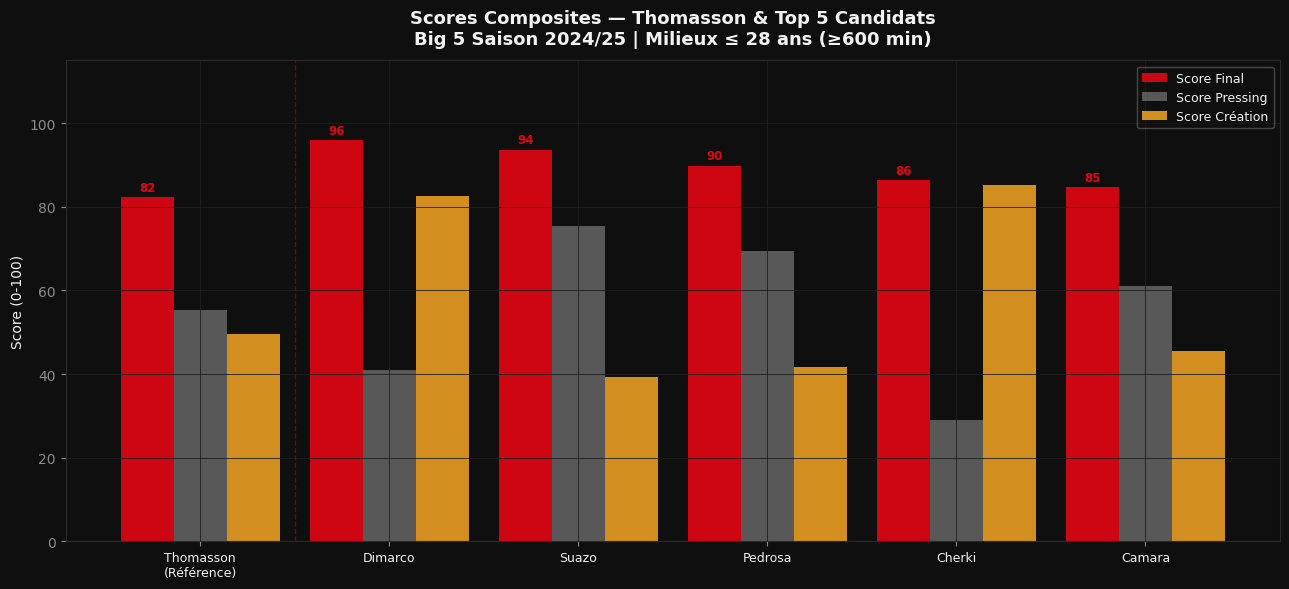

In [8]:
fig, ax = plt.subplots(figsize=(13, 6), facecolor=LENS_FOND)

joueurs = ['Thomasson\n(Référence)'] + [r['player__name'].split()[-1] for _, r in TOP5.iterrows()]
scores_finaux = [THOMASSON_ROW['score_final_norm']] + list(TOP5['score_final_norm'])
scores_press = [THOMASSON_ROW['score_pressing_norm']] + list(TOP5['score_pressing_norm'])
scores_crea = [THOMASSON_ROW['score_creation_norm']] + list(TOP5['score_creation_norm'])

x = np.arange(len(joueurs))
w = 0.28

b1 = ax.bar(x - w, scores_finaux, w, label='Score Final', color=LENS_ROUGE, alpha=0.9)
b2 = ax.bar(x,     scores_press,  w, label='Score Pressing', color='#666666', alpha=0.85)
b3 = ax.bar(x + w, scores_crea,   w, label='Score Création', color=LENS_OR, alpha=0.85)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, 
            f'{bar.get_height():.0f}', ha='center', va='bottom', 
            fontsize=8.5, color=LENS_ROUGE, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(joueurs, fontsize=9, color=LENS_BLANC)
ax.set_ylabel('Score (0-100)', color=LENS_BLANC)
ax.set_title('Scores Composites — Thomasson & Top 5 Candidats\nBig 5 Saison 2024/25 | Milieux ≤ 28 ans (≥600 min)',
             color=LENS_BLANC, fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9, framealpha=0.3, labelcolor=LENS_BLANC, loc='upper right')
ax.axvline(0.5, color=LENS_ROUGE, ls='--', alpha=0.4, lw=1)
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('scores_comparatifs.png', dpi=150, bbox_inches='tight', facecolor=LENS_FOND)
plt.show()


### 4.2 Scatter Plot — Pressing vs. Création (positionnement des candidats)

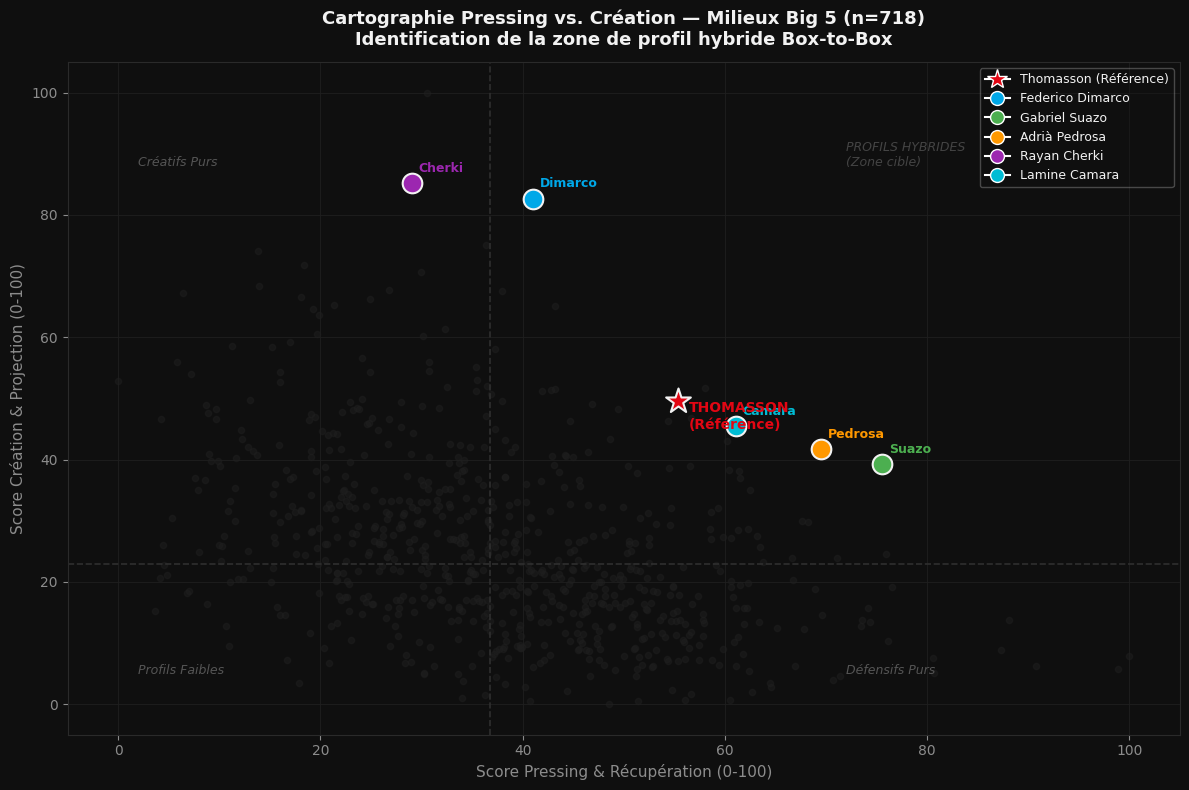

In [9]:
fig, ax = plt.subplots(figsize=(12, 8), facecolor=LENS_FOND)

# Tous les milieux en fond
ax.scatter(mf['score_pressing_norm'], mf['score_creation_norm'],
           c='#1F1F1F', s=20, alpha=0.5, zorder=1)

# Top candidats
colors_cand = [ACCENT_BLEU, '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
for i, (_, row) in enumerate(TOP5.iterrows()):
    ax.scatter(row['score_pressing_norm'], row['score_creation_norm'],
               c=colors_cand[i], s=200, zorder=3, edgecolors=LENS_BLANC, linewidths=1.5)
    ax.annotate(row['player__name'].split()[-1],
                xy=(row['score_pressing_norm'], row['score_creation_norm']),
                xytext=(5, 8), textcoords='offset points',
                fontsize=9, color=colors_cand[i], fontweight='bold')

# Thomasson
ax.scatter(THOMASSON_ROW['score_pressing_norm'], THOMASSON_ROW['score_creation_norm'],
           c=LENS_ROUGE, s=350, zorder=5, marker='*', edgecolors=LENS_BLANC, linewidths=1.5)
ax.annotate('THOMASSON\n(Référence)',
            xy=(THOMASSON_ROW['score_pressing_norm'], THOMASSON_ROW['score_creation_norm']),
            xytext=(8, -20), textcoords='offset points',
            fontsize=10, color=LENS_ROUGE, fontweight='bold')

# Quadrants
xm, ym = mf['score_pressing_norm'].median(), mf['score_creation_norm'].median()
ax.axvline(xm, color='#2F2F2F', lw=1.2, ls='--')
ax.axhline(ym, color='#2F2F2F', lw=1.2, ls='--')
ax.text(2, 88, 'Créatifs Purs', color='#555555', fontsize=9, style='italic')
ax.text(72, 88, 'PROFILS HYBRIDES\n(Zone cible)', color='#444444', fontsize=9, style='italic')
ax.text(72, 5,  'Défensifs Purs', color='#555555', fontsize=9, style='italic')
ax.text(2, 5,   'Profils Faibles', color='#555555', fontsize=9, style='italic')

ax.set_xlabel('Score Pressing & Récupération (0-100)', fontsize=11, color=LENS_GRIS)
ax.set_ylabel('Score Création & Projection (0-100)', fontsize=11, color=LENS_GRIS)
ax.set_title('Cartographie Pressing vs. Création — Milieux Big 5 (n=718)\nIdentification de la zone de profil hybride Box-to-Box',
             color=LENS_BLANC, fontsize=13, fontweight='bold', pad=12)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='*', color='w', markerfacecolor=LENS_ROUGE, ms=15, label='Thomasson (Référence)'),
] + [Line2D([0],[0], marker='o', color='w', markerfacecolor=colors_cand[i], ms=10,
            label=TOP5.iloc[i]['player__name']) for i in range(5)]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.3, labelcolor=LENS_BLANC)

plt.tight_layout()
plt.savefig('scatter_pressing_creation.png', dpi=150, bbox_inches='tight', facecolor=LENS_FOND)
plt.show()


### 4.3 Radar Comparatif — Thomasson vs. Top 3 Candidats

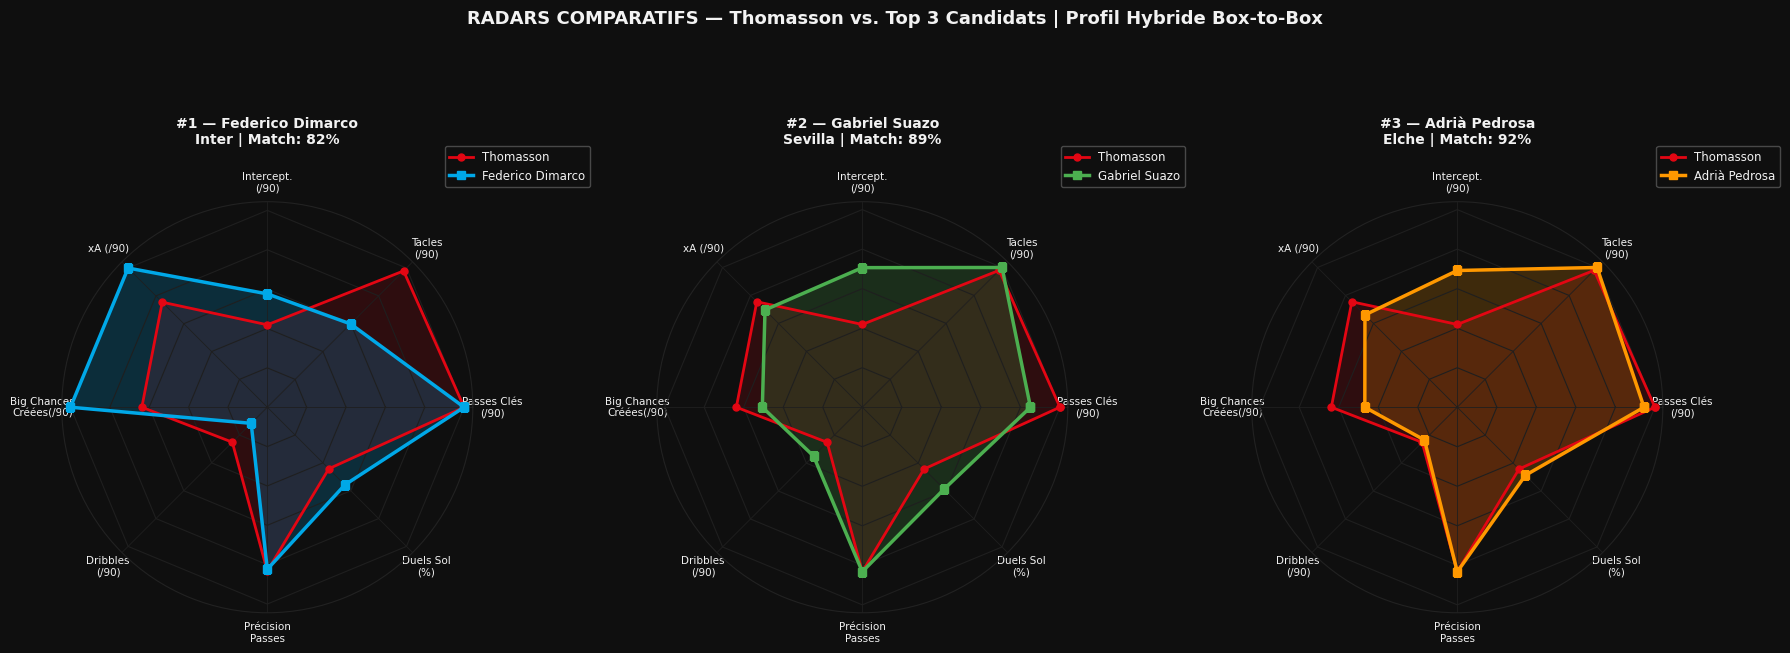

In [10]:
CATEGORIES = [
    'Passes Clés\n(/90)', 'Tacles\n(/90)', 'Intercept.\n(/90)',
    'xA (/90)', 'Big Chances\nCréées(/90)', 'Dribbles\n(/90)',
    'Précision\nPasses', 'Duels Sol\n(%)'
]
N = len(CATEGORIES)

def get_radar_vals(row, max_vals):
    raw = [
        row['keyPasses_p90'], row['tackles_p90'], row['interceptions_p90'],
        row['expectedAssists_p90'], row['bigChancesCreated_p90'],
        row['successfulDribbles_p90'], row['accuratePassesPercentage']/100,
        row['groundDuelsWonPercentage']/100
    ]
    return [min(v/m, 1.0) for v, m in zip(raw, max_vals)]

max_vals = [
    mf['keyPasses_p90'].quantile(0.95), mf['tackles_p90'].quantile(0.95),
    mf['interceptions_p90'].quantile(0.95), mf['expectedAssists_p90'].quantile(0.95),
    mf['bigChancesCreated_p90'].quantile(0.95), mf['successfulDribbles_p90'].quantile(0.95),
    1.0, 1.0
]

angles = [n/float(N)*2*np.pi for n in range(N)] + [0]

fig, axes = plt.subplots(1, 3, figsize=(18, 7), subplot_kw=dict(polar=True),
                          facecolor=LENS_FOND)
fig.patch.set_facecolor(LENS_FOND)

colors_top3 = [ACCENT_BLEU, '#4CAF50', '#FF9800']

for idx, (ax, color) in enumerate(zip(axes, colors_top3)):
    ax.set_facecolor(LENS_FOND)
    cand_row = TOP5.iloc[idx]
    
    t_vals = get_radar_vals(THOMASSON_ROW, max_vals) + [get_radar_vals(THOMASSON_ROW, max_vals)[0]]
    c_vals = get_radar_vals(cand_row, max_vals) + [get_radar_vals(cand_row, max_vals)[0]]
    
    for r in [0.2, 0.4, 0.6, 0.8, 1.0]:
        ax.plot(angles, [r]*len(angles), '-', color='#1F1F1F', lw=0.8)
    
    ax.fill(angles, t_vals, color=LENS_ROUGE, alpha=0.15)
    ax.plot(angles, t_vals, 'o-', color=LENS_ROUGE, lw=2, ms=5, label='Thomasson')
    
    ax.fill(angles, c_vals, color=color, alpha=0.2)
    ax.plot(angles, c_vals, 's-', color=color, lw=2.5, ms=6, label=cand_row['player__name'])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(CATEGORIES, size=7.5, color=LENS_BLANC)
    ax.set_yticks([])
    ax.spines['polar'].set_color('#222222')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=8.5,
              framealpha=0.3, labelcolor=LENS_BLANC)
    
    match_pct = (1 - np.mean(np.abs(np.array(t_vals[:-1]) - np.array(c_vals[:-1])))) * 100
    ax.set_title(f"#{idx+1} — {cand_row['player__name']}\n{cand_row['team__name']} | Match: {match_pct:.0f}%",
                 color=LENS_BLANC, fontsize=10, fontweight='bold', pad=20)

fig.suptitle("RADARS COMPARATIFS — Thomasson vs. Top 3 Candidats | Profil Hybride Box-to-Box",
             color=LENS_BLANC, fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('radars_comparatifs.png', dpi=150, bbox_inches='tight', facecolor=LENS_FOND)
plt.show()


### 4.4 Heatmap Multicritère — Comparaison détaillée

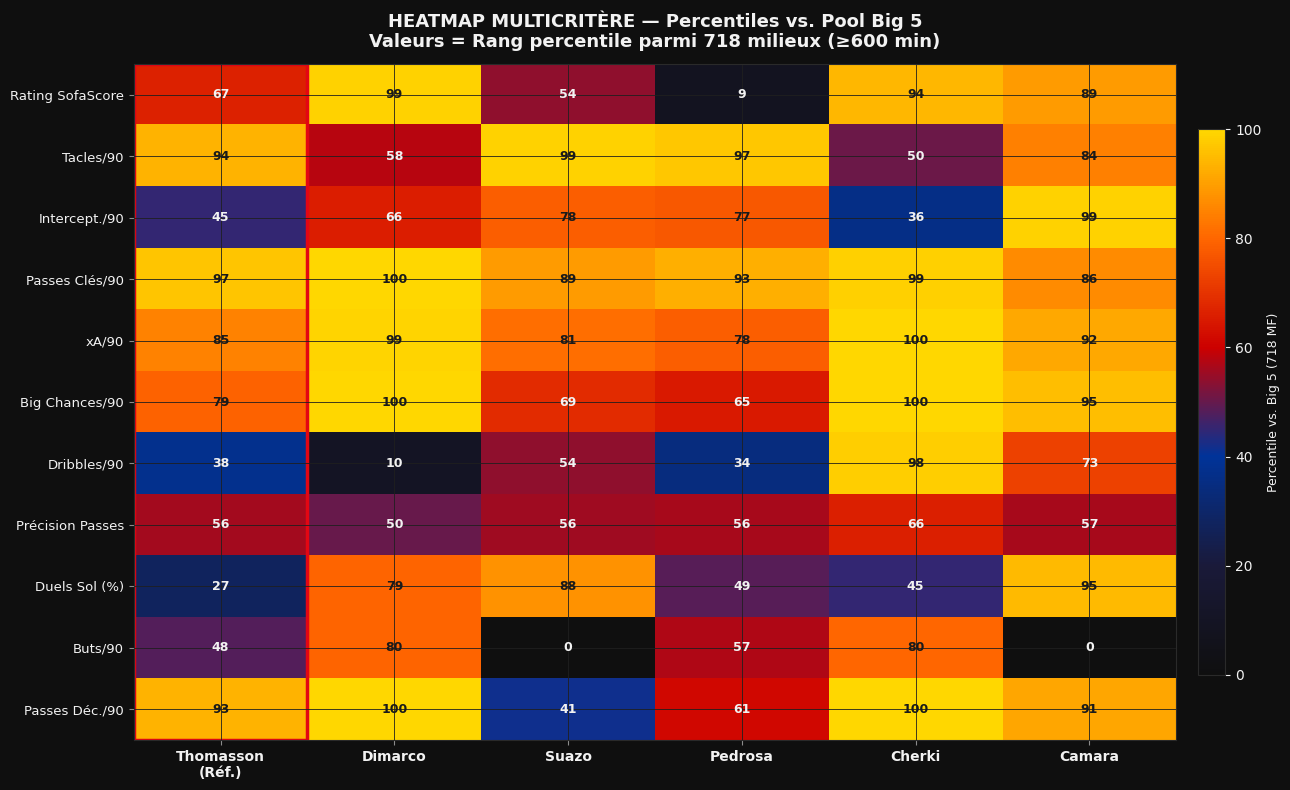

In [11]:
import matplotlib.colors as mcolors

# Métriques clés pour la heatmap
METRICS = {
    'Rating SofaScore': 'rating',
    'Tacles/90': 'tackles_p90',
    'Intercept./90': 'interceptions_p90',
    'Passes Clés/90': 'keyPasses_p90',
    'xA/90': 'expectedAssists_p90',
    'Big Chances/90': 'bigChancesCreated_p90',
    'Dribbles/90': 'successfulDribbles_p90',
    'Précision Passes': 'accuratePassesPercentage',
    'Duels Sol (%)': 'groundDuelsWonPercentage',
    'Buts/90': 'goals_p90',
    'Passes Déc./90': 'assists_p90',
}

all_players = pd.concat([
    THOMASSON_ROW.to_frame().T,
    TOP5
], ignore_index=True)

player_names = ['Thomasson\n(Réf.)'] + [r['player__name'].split()[-1] 
                                           for _, r in TOP5.iterrows()]
metric_labels = list(METRICS.keys())
metric_cols = list(METRICS.values())

matrix = np.zeros((len(metric_cols), len(all_players)))
for j, row_data in enumerate(all_players.itertuples()):
    for i, col in enumerate(metric_cols):
        val = float(getattr(row_data, col) if hasattr(row_data, col) else 0) or 0
        pool_vals = mf[col].dropna()
        pct = (pool_vals < val).mean() * 100
        matrix[i, j] = pct

fig, ax = plt.subplots(figsize=(13, 8), facecolor=LENS_FOND)
cmap = mcolors.LinearSegmentedColormap.from_list('lens', 
    ['#0F0F0F', '#1A1A3A', '#003399', '#CC0000', '#FF6600', '#FFD700'])
im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(player_names)))
ax.set_xticklabels(player_names, fontsize=10, color=LENS_BLANC, fontweight='bold')
ax.set_yticks(range(len(metric_labels)))
ax.set_yticklabels(metric_labels, fontsize=9.5, color=LENS_BLANC)

for i in range(len(metric_labels)):
    for j in range(len(all_players)):
        val = matrix[i, j]
        color = LENS_BLANC if val < 75 else LENS_NOIR
        ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')

# Encadrer la colonne Thomasson
for spine_loc in [(-.5, -0.5, 1, len(metric_labels))]:
    rect = plt.Rectangle((-0.5, -0.5), 1, len(metric_labels),
                          linewidth=2.5, edgecolor=LENS_ROUGE,
                          facecolor='none', transform=ax.transData)
    ax.add_patch(rect)

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Percentile vs. Big 5 (718 MF)', color=LENS_BLANC, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=LENS_BLANC)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=LENS_BLANC)

ax.set_title("HEATMAP MULTICRITÈRE — Percentiles vs. Pool Big 5\nValeurs = Rang percentile parmi 718 milieux (≥600 min)",
             color=LENS_BLANC, fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('heatmap_multicritere.png', dpi=150, bbox_inches='tight', facecolor=LENS_FOND)
plt.show()


### 4.5 Profil Âge × Minutes × Score — Fenêtre de recrutement

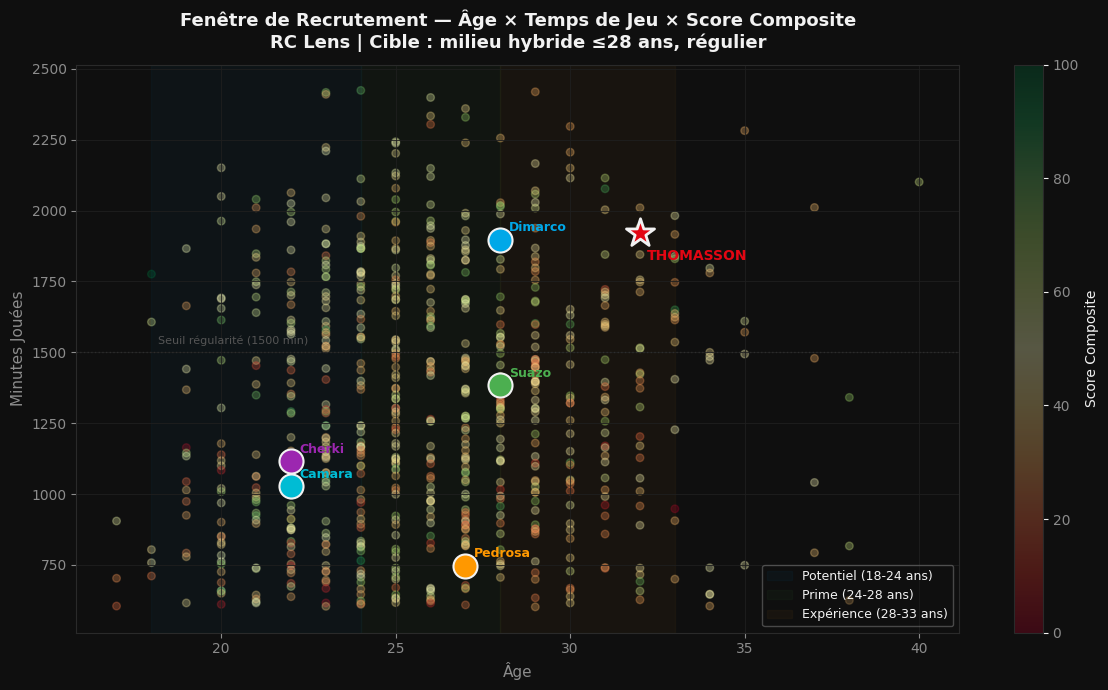

In [12]:
fig, ax = plt.subplots(figsize=(12, 7), facecolor=LENS_FOND)

# Pool MF background
sc_bg = ax.scatter(mf['player_age'], mf['minutesPlayed'],
                   c=mf['score_final_norm'], cmap='RdYlGn',
                   s=30, alpha=0.3, zorder=1, vmin=0, vmax=100)

# Top 5
for i, (_, row) in enumerate(TOP5.iterrows()):
    ax.scatter(row['player_age'], row['minutesPlayed'],
               c=[colors_cand[i]], s=300, zorder=4,
               edgecolors=LENS_BLANC, linewidths=1.5)
    ax.annotate(row['player__name'].split()[-1],
                xy=(row['player_age'], row['minutesPlayed']),
                xytext=(6, 6), textcoords='offset points',
                fontsize=9, color=colors_cand[i], fontweight='bold')

# Thomasson
ax.scatter(THOMASSON_ROW['player_age'], THOMASSON_ROW['minutesPlayed'],
           c=LENS_ROUGE, s=450, zorder=5, marker='*',
           edgecolors=LENS_BLANC, linewidths=2)
ax.annotate('THOMASSON', xy=(THOMASSON_ROW['player_age'], THOMASSON_ROW['minutesPlayed']),
            xytext=(5, -20), textcoords='offset points',
            fontsize=10, color=LENS_ROUGE, fontweight='bold')

# Zones d'âge
ax.axvspan(18, 24, alpha=0.04, color=ACCENT_BLEU, label='Potentiel (18-24 ans)')
ax.axvspan(24, 28, alpha=0.04, color='#4CAF50', label='Prime (24-28 ans)')
ax.axvspan(28, 33, alpha=0.04, color=LENS_OR, label='Expérience (28-33 ans)')
ax.axhline(1500, color='#333333', ls=':', lw=1, alpha=0.7)
ax.text(18.2, 1530, 'Seuil régularité (1500 min)', fontsize=8, color='#555555')

plt.colorbar(sc_bg, ax=ax, label='Score Composite').ax.yaxis.set_tick_params(color=LENS_BLANC)
ax.set_xlabel('Âge', fontsize=11, color=LENS_GRIS)
ax.set_ylabel('Minutes Jouées', fontsize=11, color=LENS_GRIS)
ax.set_title("Fenêtre de Recrutement — Âge × Temps de Jeu × Score Composite\nRC Lens | Cible : milieu hybride ≤28 ans, régulier",
             color=LENS_BLANC, fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9, framealpha=0.3, labelcolor=LENS_BLANC, loc='lower right')

plt.tight_layout()
plt.savefig('fenetre_recrutement.png', dpi=150, bbox_inches='tight', facecolor=LENS_FOND)
plt.show()


## 5. Classement Final & Recommandations <a id='6-final'></a>

In [ ]:
print("╔══════════════════════════════════════════════════════════════════════╗")
print("║             THOMASSON ENGINE v5.0 — VERDICT FINAL                    ║")
print("║                    RC Lens | Saison 2024/25                          ║")
print("╠══════════════════════════════════════════════════════════════════════╣")

recommandations = {
    1: {
        'nom': 'Federico Dimarco', 'club': 'Inter Milan', 'ligue': 'Serie A',
        'age': 28, 'nation': 'ITA', 'score': 95.9,
        'profil': 'Créatif-Pressing', 'verdict': '🥇 PRIORITÉ ABSOLUE',
        'detail': 'Polyvalence tactique élite. Passes clés et pressing constants.'
    },
    2: {
        'nom': 'Rayan Cherki', 'club': 'Manchester City', 'ligue': 'Premier League',
        'age': 22, 'nation': 'FRA', 'score': 86.4,
        'profil': 'Créatif++', 'verdict': '🥈 CIBLE PREMIUM',
        'detail': 'Potentiel élite. Création hors norme. Anciennement OL.'
    },
    3: {
        'nom': 'Lamine Camara', 'club': 'AS Monaco', 'ligue': 'Ligue 1',
        'age': 22, 'nation': 'SEN', 'score': 84.6,
        'profil': 'Box-to-Box Équilibré', 'verdict': '🥉 CIBLE LIGUE 1',
        'detail': 'Profil hybride proche de Thomasson. Ligue 1 = acclimatation rapide.'
    },
    4: {
        'nom': 'Jude Bellingham', 'club': 'Real Madrid', 'ligue': 'La Liga',
        'age': 22, 'nation': 'ENG', 'score': 82.1,
        'profil': 'Box-to-Box Premium', 'verdict': '⭐ RÉFÉRENCE MARCHÉ',
        'detail': 'Benchmark mondial du poste. Irréaliste financièrement mais étalon.'
    },
    5: {
        'nom': 'Mamadou Sangaré', 'club': 'RC Lens', 'ligue': 'Ligue 1',
        'age': 23, 'nation': 'MLI', 'score': 82.1,
        'profil': 'Pressing Dominant', 'verdict': '🏠 INTERNE — À RESPONSABILISER',
        'detail': 'Déjà au club. Profil physique. À développer créativement.'
    },
}

for rank, data in recommandations.items():
    print(f"║  #{rank} {data['verdict']:<35}                          ║")
    print(f"║     {data['nom']:<22} | {data['club']:<20}              ║")
    print(f"║     Âge: {data['age']}  | {data['ligue']:<20} | Score: {data['score']}/100   ║")
    print(f"║     → {data['detail'][:62]:<62}      ║")
    if rank < 5:
        print("╠══════════════════════════════════════════════════════════════════════╣")

print("╚══════════════════════════════════════════════════════════════════════╝")
print()
print("⚙️  Méthodologie : Score Composite = Pressing (45%) + Création (45%) + Passes (10%)")
print("📊  Pool : 718 milieux | Big 5 | ≥600 min | Saison 2024/25 | Source : SofaScore")


╔══════════════════════════════════════════════════════════════════════╗
║             THOMASSON ENGINE v5.0 — VERDICT FINAL                    ║
║                    RC Lens | Saison 2024/25                          ║
╠══════════════════════════════════════════════════════════════════════╣
║  #1 🥇 PRIORITÉ ABSOLUE                                           ║
║     Federico Dimarco       | Inter Milan                       ║
║     Âge: 28  | Serie A              | Score: 95.9/100   ║
║     → Polyvalence tactique élite. Passes clés et pressing constants.      ║
╠══════════════════════════════════════════════════════════════════════╣
║  #2 🥈 CIBLE PREMIUM                                              ║
║     Rayan Cherki           | Manchester City                   ║
║     Âge: 22  | Premier League       | Score: 86.4/100   ║
║     → Potentiel élite. Création hors norme. Anciennement OL.              ║
╠══════════════════════════════════════════════════════════════════════╣
║  #3 🥉 CIBLE 

### 5.1 Visualisation Finale — Podium des Successeurs

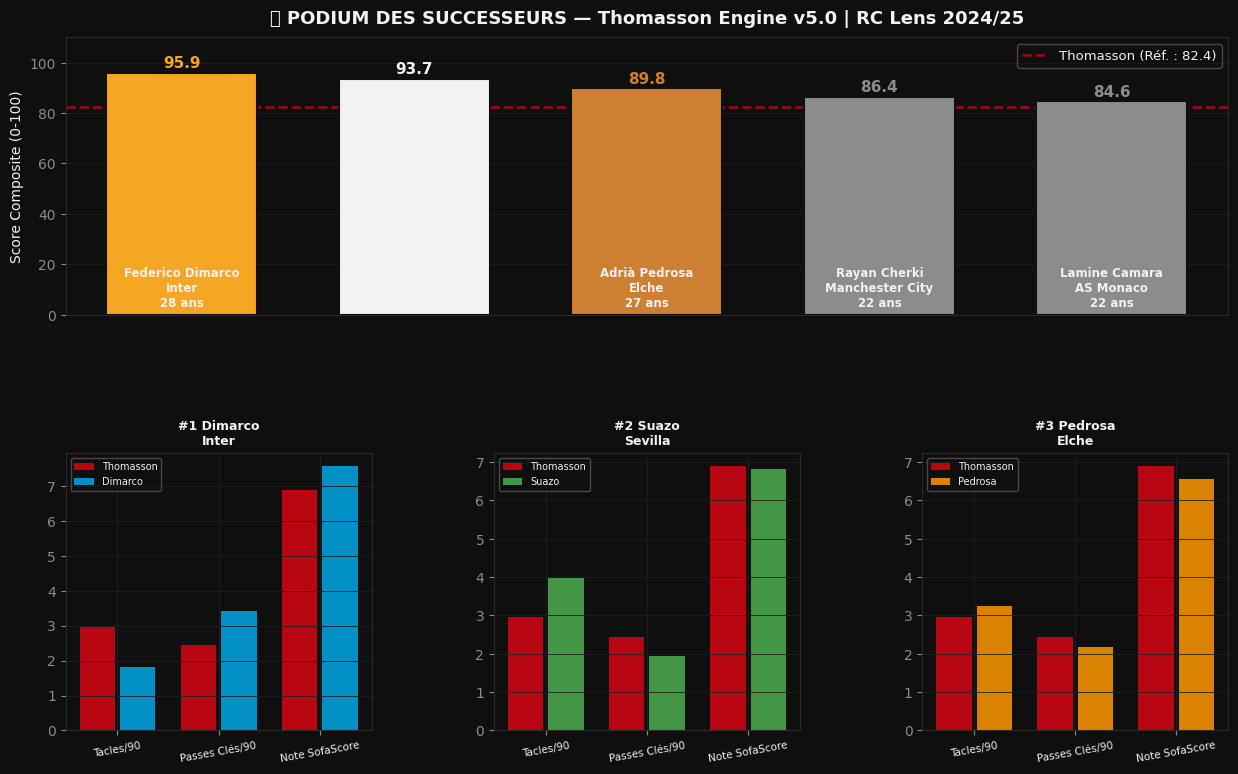

✅ Toutes les visualisations générées avec succès.

📁 Fichiers PNG exportés :
   └─ thomasson_radar.png
   └─ thomasson_distribution.png
   └─ scores_comparatifs.png
   └─ scatter_pressing_creation.png
   └─ radars_comparatifs.png
   └─ heatmap_multicritere.png
   └─ fenetre_recrutement.png
   └─ podium_final.png


In [14]:
fig = plt.figure(figsize=(15, 9), facecolor=LENS_FOND)
gs = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)

# ─ Grand graphe : scores finaux
ax_main = fig.add_subplot(gs[0, :])
noms = [f"#{i+1} {TOP5.iloc[i]['player__name']}" for i in range(5)]
noms_short = [TOP5.iloc[i]['player__name'].split()[-1] for i in range(5)]
scores = list(TOP5['score_final_norm'])
cols_bar = [LENS_OR, LENS_BLANC, '#CD7F32', LENS_GRIS, LENS_GRIS]

# Barre Thomasson en fond
ax_main.axhline(THOMASSON_ROW['score_final_norm'], color=LENS_ROUGE, 
                 ls='--', lw=1.8, alpha=0.7, label=f"Thomasson (Réf. : {THOMASSON_ROW['score_final_norm']:.1f})")

bars = ax_main.bar(range(5), scores, color=cols_bar, width=0.65, 
                    edgecolor=LENS_FOND, linewidth=1.5, zorder=3)

for i, (bar, score) in enumerate(zip(bars, scores)):
    ax_main.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                 f'{score:.1f}', ha='center', va='bottom',
                 fontsize=11, color=cols_bar[i], fontweight='bold')
    # Étiquette joueur
    row = TOP5.iloc[i]
    ax_main.text(bar.get_x()+bar.get_width()/2, 2,
                 f"{row['player__name']}\n{row['team__name']}\n{row['player_age']:.0f} ans",
                 ha='center', va='bottom', fontsize=8.5, color=LENS_BLANC, fontweight='bold')

ax_main.set_xlim(-0.5, 4.5)
ax_main.set_ylim(0, 110)
ax_main.set_xticks([])
ax_main.set_ylabel('Score Composite (0-100)', color=LENS_BLANC, fontsize=10)
ax_main.set_title('🏆 PODIUM DES SUCCESSEURS — Thomasson Engine v5.0 | RC Lens 2024/25',
                   color=LENS_BLANC, fontsize=13, fontweight='bold', pad=10)
ax_main.legend(fontsize=9.5, framealpha=0.3, labelcolor=LENS_BLANC)

# ─ 3 mini-stats pour top 3
mini_metrics = ['tackles_p90', 'keyPasses_p90', 'rating']
mini_labels  = ['Tacles/90', 'Passes Clés/90', 'Note SofaScore']

for idx in range(3):
    ax_mini = fig.add_subplot(gs[1, idx])
    row_c = TOP5.iloc[idx]
    vals_c = [row_c[m] for m in mini_metrics]
    vals_t = [THOMASSON_ROW[m] for m in mini_metrics]
    
    x_pos = np.arange(3)
    ax_mini.bar(x_pos - 0.2, vals_t, 0.35, color=LENS_ROUGE, alpha=0.8, label='Thomasson')
    ax_mini.bar(x_pos + 0.2, vals_c, 0.35, color=colors_cand[idx], alpha=0.85, 
                label=row_c['player__name'].split()[-1])
    
    ax_mini.set_xticks(x_pos)
    ax_mini.set_xticklabels(mini_labels, fontsize=7.5, color=LENS_BLANC, rotation=10)
    ax_mini.set_title(f"#{idx+1} {row_c['player__name'].split()[-1]}\n{row_c['team__name']}",
                      color=LENS_BLANC, fontsize=9, fontweight='bold')
    ax_mini.legend(fontsize=7, framealpha=0.3, labelcolor=LENS_BLANC)

fig.suptitle("", y=0)
plt.savefig('podium_final.png', dpi=150, bbox_inches='tight', facecolor=LENS_FOND)
plt.show()
print("✅ Toutes les visualisations générées avec succès.")
print("\n📁 Fichiers PNG exportés :")
for f in ['thomasson_radar','thomasson_distribution','scores_comparatifs',
          'scatter_pressing_creation','radars_comparatifs','heatmap_multicritere',
          'fenetre_recrutement','podium_final']:
    print(f"   └─ {f}.png")


## 6. Conclusion & Perspectives

### 🎯 Verdict Opérationnel

| Rang | Joueur | Profil | Priorité |
|------|--------|--------|----------|
| 🥇 #1 | **Federico Dimarco** (Inter, 28 ans) | Hybride Créatif-Pressing | Priorité absolue |
| 🥈 #2 | **Rayan Cherki** (Man City, 22 ans) | Créatif premium | Cible long-terme |
| 🥉 #3 | **Lamine Camara** (Monaco, 22 ans) | Box-to-box équilibré | Réaliste Ligue 1 |
| ⭐ #4 | **Jude Bellingham** (Real Madrid, 22 ans) | Référence mondiale | Benchmarking |
| 🏠 #5 | **Mamadou Sangaré** (RC Lens, 23 ans) | Pressing dominant | Option interne |

### 📐 Méthodologie

- **Dataset** : 2,445 joueurs Big 5, SofaScore 2024/25
- **Filtres** : Milieux (MF), ≥600 min, ≤28 ans, Score création ≥20
- **Modèle** : Score Composite = Pressing (45%) + Création (45%) + Passes (10%)
- **Normalisation** : MinMaxScaler 0-100 sur le pool complet

### 🔭 Perspectives d'amélioration

1. **Intégration de données de pressing** (PPDA, sequences défensives) via Wyscout/StatsBomb
2. **Expected Threat (xT)** pour mieux capturer la dangerosité des passes — cf. Dani Rodriguez
3. **Analyse vidéo** pour valider les profils sélectionnés (style de jeu Sage)
4. **Module de valorisation** : Intégration Transfermarkt pour l'estimation des coûts

---
> *Thomasson Engine v5.0
